In [1]:
import numpy as np
from tqdm import tqdm
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter

import torch
import torch.nn as nn
import torch.nn.functional as F

from utils_stream import *

Torch version: 2.2.1+cu118


In [2]:
class LogisticRegressionTorch(nn.Module):
    def __init__(self, input_size, num_classes):
        super(LogisticRegressionTorch, self).__init__()
        self.layer_norm = nn.LayerNorm(input_size)
        self.linear_1 = nn.Linear(input_size, 256)
        self.linear_2 = nn.Linear(256, 128)
        self.linear_3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.layer_norm(x)
        x = F.relu(self.linear_1(x))
        x = F.relu(self.linear_2(x))
        x = self.linear_3(x)
        return x

    def load(self, path):
        state_dict = torch.load(path)
        self.load_state_dict(state_dict)

In [3]:
CLIP_encoder_path = 'sources/model.pt'
classifier_path = 'sources/28_05_50.46_linear_model29_mlp.pth'

In [4]:
CLIP_encoder = load_model(CLIP_encoder_path)

CLIP (ViT-B/32)
Model parameters: 151'277'313
Input resolution: 224
Context length: 77
Vocab size: 49408


In [5]:
classifier = LogisticRegressionTorch(input_size=512, num_classes=7).to('cuda')
classifier.load(classifier_path)
classifier.eval()

LogisticRegressionTorch(
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (linear_1): Linear(in_features=512, out_features=256, bias=True)
  (linear_2): Linear(in_features=256, out_features=128, bias=True)
  (linear_3): Linear(in_features=128, out_features=7, bias=True)
)

In [7]:
classes = {
    'Arson': 0,
    'Assault': 1,
    'Explosion': 2,
    'Fighting': 3,
    'RoadAccidents': 4,
    'Vandalism': 5,
    'Normal': 6,
}

In [8]:
def info_about_video(video_path):
        
    try:
        # Открытие видеофайла
        video_capture = cv2.VideoCapture(video_path)

        # Проверка успешности открытия видеофайла
        if not video_capture.isOpened():
            raise FileNotFoundError(f'Файл {video_path} не найден или не может быть прочитан')

        # Вычисление количества кадров, которые нужно пропустить для заданного fps
        total_frames = video_capture.get(cv2.CAP_PROP_FRAME_COUNT)
        frame_rate = video_capture.get(cv2.CAP_PROP_FPS)

        # Вывод информации о видеофайле
        full_time = time_to_str(total_frames/frame_rate)
        print(f'Файл: {video_path}, продолжительность: {full_time}, частота кадров (fps): {frame_rate}')

        return [total_frames, frame_rate, full_time]
    
    except Exception as e:
        # Вывод сообщения об ошибке
        print(f"Ошибка: {e}")
    
    finally:
        # Закрытие видеофайла в любом случае
        if 'video_capture' in locals() and video_capture.isOpened():
            video_capture.release()

In [9]:
def classify_video_by_frames(encoder, classifier, video_path, fps):
        
    try:
        # Открытие видеофайла
        video_capture = cv2.VideoCapture(video_path)

        # Проверка успешности открытия видеофайла
        if not video_capture.isOpened():
            raise FileNotFoundError(f'Файл {video_path} не найден или не может быть прочитан')

        # Вычисление количества кадров, которые нужно пропустить для заданного fps
        total_frames = video_capture.get(cv2.CAP_PROP_FRAME_COUNT)
        frame_rate = video_capture.get(cv2.CAP_PROP_FPS)
        fps = frame_rate if fps == 'max' else fps
        skip_frames = frame_rate / fps

        # Вывод информации о видеофайле
        full_time = time_to_str(total_frames/frame_rate)
        print(f'Файл: {video_path}, продолжительность: {full_time}, частота кадров (fps): {frame_rate}')
        
        # Создание объекта Compose для предобработки изображения
        preprocess = Compose([Resize((224,224), interpolation=Image.BICUBIC), ToTensor()])
        
        pred_dict = {'time_str': [], 'time': []}
        for cl_col in classes.keys():
            pred_dict[cl_col] = []
        pred_dict['pred'] = []

        # Итеративное извлечение нужных кадров
        # for frame_number in range(0, int(total_frames), int(skip_frames)):
        for frame_number in tqdm(range(0, int(total_frames), int(skip_frames))):
            video_capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
            ret, frame = video_capture.read()

            # Проверка успешности извлечения кадра
            if not ret:
                # raise RuntimeError('Ошибка при извлечении кадра')
                print('Ошибка при извлечении кадра')
                continue

            # Преобразование кадра в нужный формат
            frame_tensor = preprocess_image(encoder, frame, preprocess)

            with torch.no_grad():
                frame_preds = classifier(frame_tensor)
                frame_probs = torch.sigmoid(frame_preds)
                frame_class = torch.argmax(frame_probs, dim=1)

            pred_dict['time_str'].append(time_to_str(frame_number / frame_rate))
            pred_dict['time'].append(frame_number / frame_rate)
            for cl_col, cl_num in classes.items():
                pred_dict[cl_col].append(frame_probs[0][cl_num].item())
            pred_dict['pred'].append(frame_class.item())
        
        pred_df = pd.DataFrame(pred_dict)

    except Exception as e:
        # Вывод сообщения об ошибке
        print(f"Ошибка: {e}")
    
    finally:
        # Закрытие видеофайла в любом случае
        if 'video_capture' in locals() and video_capture.isOpened():
            video_capture.release()

    return pred_df

In [442]:
video_dir = 'diff_videos/0010'

video_path = f'{video_dir}/{video_dir.split("/")[-1]}.mp4'
# video_path = f'{video_dir}/{video_dir.split("/")[-1]}.mov'
video_info = info_about_video(video_path)

Файл: diff_videos/0010/0010.mp4, продолжительность: 00:12.500, частота кадров (fps): 30.0


In [443]:
fps = video_info[1] * 1/3

In [444]:
pred_df = classify_video_by_frames(CLIP_encoder, classifier, video_path, fps)

Файл: diff_videos/0010/0010.mp4, продолжительность: 00:12.500, частота кадров (fps): 30.0


100%|██████████| 125/125 [00:43<00:00,  2.89it/s]


In [445]:
csv_path = video_path.split('.')[0] + '.csv'
pred_df.to_csv(csv_path)

In [400]:
csv_dir = 'diff_videos/bel_0'

csv_path = f'{csv_dir}/{csv_dir.split("/")[-1]}.csv'
pred_df = pd.read_csv(csv_path)
pred_df = pred_df.drop(columns=['Unnamed: 0'])

In [446]:
pred_df

,time_str,time,Arson,Assault,Explosion,Fighting,RoadAccidents,Vandalism,Normal,pred
0,00:00.000,0.0,8.301033e-05,0.453516,0.002391,0.014225,0.004983,0.007658,0.193447,1
1,00:00.100,0.1,4.337414e-05,0.003203,0.001500,0.009545,0.000336,0.003591,0.993043,6
2,00:00.200,0.2,2.432586e-05,0.000694,0.000897,0.002777,0.000108,0.001933,0.999545,6
3,00:00.300,0.3,2.030092e-05,0.000175,0.000067,0.002407,0.000074,0.001089,0.999891,6
4,00:00.400,0.4,1.061238e-05,0.000066,0.000030,0.001569,0.000036,0.001207,0.999970,6
...,...,...,...,...,...,...,...,...,...,...
120,00:12.000,12.0,3.301913e-06,0.000108,0.000043,0.001872,0.000834,0.002385,0.999430,6
121,00:12.100,12.1,2.381763e-06,0.000053,0.000076,0.002691,0.000978,0.024559,0.998655,6
122,00:12.200,12.2,1.012609e-06,0.000018,0.000029,0.000718,0.000239,0.008590,0.999880,6
123,00:12.300,12.3,2.317266e-07,0.000010,0.000012,0.000341,0.000064,0.001786,0.999986,6


In [447]:
pred_df.describe()

,time,Arson,Assault,Explosion,Fighting,RoadAccidents,Vandalism,Normal,pred
count,125.000000,1.250000e+02,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000
mean,6.200000,6.038751e-05,0.022135,0.002931,0.030443,0.041683,0.051140,0.760899,5.656000
std,3.622844,8.825549e-05,0.081765,0.007134,0.050146,0.088743,0.099405,0.336026,0.959704
min,0.000000,2.317266e-07,0.000006,0.000007,0.000192,0.000012,0.000302,0.008436,1.000000
25%,3.100000,1.017917e-05,0.000116,0.000091,0.003321,0.000761,0.003501,0.555919,6.000000
50%,6.200000,2.271035e-05,0.000672,0.000639,0.010997,0.006884,0.016825,0.968160,6.000000
75%,9.300000,7.195722e-05,0.005982,0.002408,0.038983,0.033035,0.051301,0.997886,6.000000
max,12.400000,5.232941e-04,0.651558,0.061006,0.394098,0.544119,0.712616,0.999996,6.000000


In [161]:
def plot_preds(df, classes, size, xticks, col_n='all'):

    fig, ax = plt.subplots(figsize=size)

    if isinstance(col_n, int):
        if (col_n >= 0) and (col_n <= 7):
            ax.plot(df['time_str'], df[df.columns[col_n + 2]], label=df.columns[col_n + 2])
    
    if isinstance(col_n, list):
        for col in col_n:
            if (col >= 0) and (col <= 7):
                ax.plot(df['time_str'], df[df.columns[col + 2]], label=df.columns[col + 2])

    if isinstance(col_n, str):
        if col_n == 'all':
            for col in classes.keys():
                ax.plot(df['time_str'], df[col], label=col)

    ax.set_xlim((df['time_str'].iloc[0], df['time_str'].iloc[-1]))
    fps = int(1 / (df['time'].iloc[1] - df['time'].iloc[0]))
    ax.set_xticks(df['time_str'][::int(fps*xticks)])
    ax.tick_params(axis='x', rotation=90)
    ax.legend(loc='upper left')
    ax.grid(True)
    
    return fig

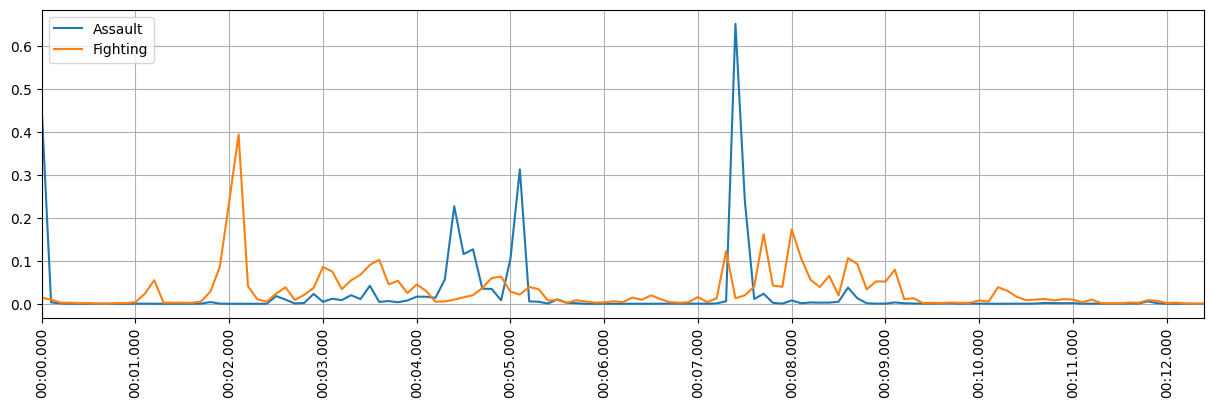

In [449]:
plot_preds(pred_df, classes, [15, 4], 1, [1, 3])

In [240]:
def get_borders(frame):

    for h in range(frame.shape[0]):
        row = frame[h]
        if [0, 0, 0] in row:
            h_up = h
            break

    for w in range(frame.shape[1]):
        val = frame[h_up][w]
        if val.all() == 0:
            w_left = w
            break

    for w in range(frame.shape[1] - 1, 0, -1):
        val = frame[h_up][w]
        if val.all() == 0:
            w_right = w
            break

    for h in range(h_up, frame.shape[0]):
        val = frame[h][w_right]
        if val.all() != 0:
            h_down = h - 1
            break

    return [w_left, w_right], [h_up, h_down]

In [277]:
def animate_plot(output_path, video_info, fps, size, df, classes, xticks, col_n='all'):

    base_frame = np.ones((size[1], size[0], 3), dtype=np.uint8) * 255
    # print(base_frame.shape)

    tmp_path = '/'.join(output_path.split('/')[:-1]) + '/tmp.png'
    
    plt.ioff()
    fig = plot_preds(df, classes, [int(size[0]/100), int(size[1]/100)], xticks, col_n)
    fig.tight_layout()
    fig.savefig(tmp_path, bbox_inches='tight')
    plt.close(fig)
    
    plot = cv2.imread(tmp_path)
    plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
    os.remove(tmp_path)
    # print(plot.shape)

    w_tab = int((size[0] - plot.shape[1]) / 2)
    h_tab = int((size[1] - plot.shape[0]) / 2)
    base_frame[h_tab:plot.shape[0]+h_tab, w_tab:plot.shape[1]+w_tab, :] = plot
    # print(h_tab, w_tab)
    
    with FFMPEG_VideoWriter(output_path, (size[0], size[1]), video_info[1]) as writer:

        w_bor, h_bor = get_borders(base_frame)
        w_step = (w_bor[1] + 1 - w_bor[0]) / video_info[0]
        # print(w_bor, w_step, h_bor)

        for i in tqdm(range(int(video_info[0]))):

            frame = base_frame.copy()

            beg_point = (round(w_bor[0] + i * w_step), h_bor[0])
            end_point = (round(w_bor[0] + i * w_step), h_bor[1])
            cv2.line(frame, beg_point, end_point, (255, 0, 0), 2)
            
            writer.write_frame(frame)

    return base_frame, plot, frame

In [450]:
output_path = video_path.split('.')[0] + '_animation.mp4'
# output_path = csv_path.split('.')[0] + '_animation.mp4'

base_frame, plot, last_frame = animate_plot(output_path, video_info, fps, [1200, 500], pred_df, classes, 1, [1, 3])

100%|██████████| 375/375 [00:03<00:00, 100.25it/s]


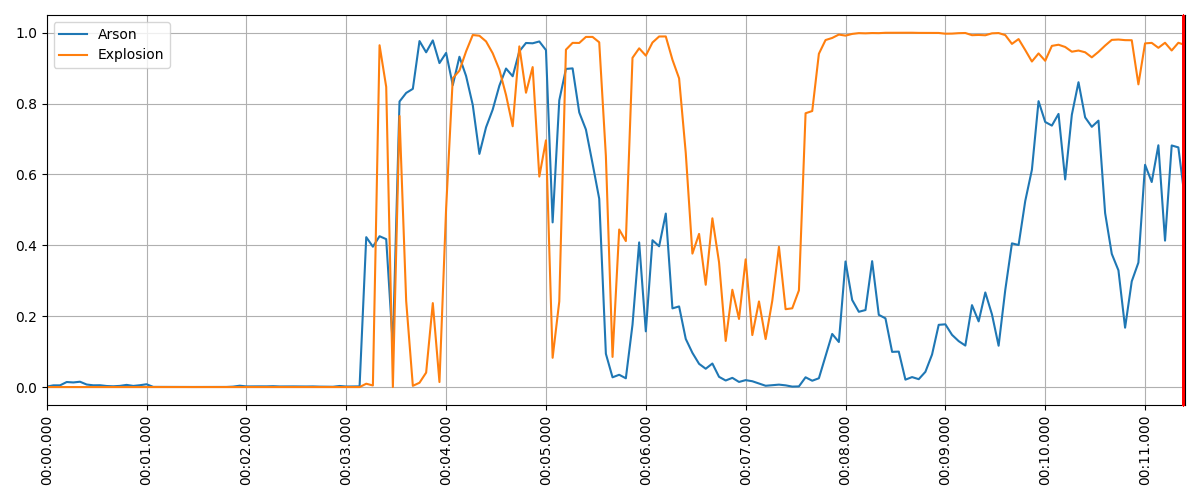

In [260]:
Image.fromarray(last_frame)

In [222]:
last_frame.shape

(500, 1500, 3)

In [81]:
cv2.imshow('last_frame', last_frame)
cv2.waitKey()
cv2.destroyAllWindows()

In [44]:
cv2.imshow('plot', plot)
cv2.waitKey()
cv2.destroyAllWindows()

In [47]:
cv2.imshow('base_frame', base_frame)
cv2.waitKey()
cv2.destroyAllWindows()

In [172]:
frame = np.ones([6, 2])
frame.resize([4, 4])

In [173]:
frame

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [0., 0., 0., 0.]])

In [60]:
test_img_path = 'data_test/1.png'

In [65]:
test_img = cv2.imread(test_img_path)
test_img_tensor = preprocess_image(CLIP_encoder, test_img, preprocess)
test_pred = classifier(test_img_tensor)
test_probs = torch.sigmoid(test_pred)
test_class = torch.argmax(test_pred, dim=1)

In [62]:
test_pred

tensor([[  4.1708,  -6.6812,  -6.7178, -13.9783,  -5.4717,  -8.5307, -16.9923]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [72]:
test_probs[0][0].item()

0.9847943186759949

In [63]:
test_class.item()

0

In [11]:
for key, value in model.items():
    print(key)
    print(len(value))
    print()

layer_norm.weight
512

layer_norm.bias
512

linear_1.weight
256

linear_1.bias
256

linear_2.weight
128

linear_2.bias
128

linear_3.weight
7

linear_3.bias
7



In [ ]:
dir = 'diff_videos'

names = []
for file in sorted(os.listdir(dir)):
    names.append(file.split('.')[0])
names_unique = sorted(list(set(names)))

for name in names_unique:
    os.makedirs(f'{dir}/{name}', exist_ok=True)
import shutil

for file in sorted(os.listdir(dir)):
    if os.path.isfile(f'{dir}/{file}'):
        name = file.split('.')[0]
        shutil.move(f'{dir}/{file}', f'{dir}/{name}/{file}')